In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import figurefirst as fifi
###
from mpl_toolkits import mplot3d

from splitflow.PlotUtilities import *
plt.rcParams['font.serif'] = ['Times'] + plt.rcParams['font.serif']

plt.rcParams['text.usetex'] = False
plt.rcParams["ps.usedistiller"] = 'xpdf'
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.weight'] = 'normal'
plt.rcParams["mathtext.fontset"] = 'cm'


Using device: cpu


In [2]:
layout = fifi.svg_to_axes.FigureLayout('../S1_VerticalSplit.svg', autogenlayers=True, make_mplfigures=True, hide_layers=[])

# from matplotlib import ScaleBar
#scalebar = ScaleBar(200, "cm", length_fraction=.2, label='0.2 m', location='upper right')
#ax[0,0].add_artist(scalebar)


FileNotFoundError: [Errno 2] No such file or directory: '../S1_VerticalSplit.svg'

# Right Fans On (y<0)

In [3]:
right1 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_rightlaminar/20240507_175627_trimmed.csv')
right2 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_rightlaminar/20240508_181730_trimmed.csv')
right3 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_rightlaminar/20240509_165127_full_trim_protocol.csv')


In [4]:
df_right_on = pd.concat([right1,right2,right3])

In [5]:
df_right_on['ground speed'] = np.sqrt(df_right_on.xvel**2 + df_right_on.yvel**2)

In [6]:
df_flash_right_on = df_right_on[df_right_on.duration>0]
df_sham_right_on =df_right_on[df_right_on.duration==0]


In [7]:
flash_left_right_on = df_flash_right_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()>0)
flash_right_right_on  = df_flash_right_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()<0)

sham_left_right_on =df_sham_right_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()>0)
sham_right_right_on =df_sham_right_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()<0)


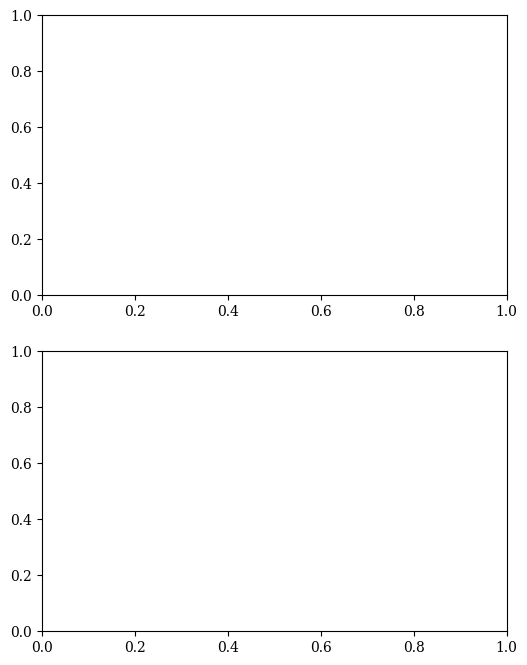

In [72]:
fig, ax = plt.subplots(figsize=(6,8), ncols=1,nrows=2)
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('A1', 'a1')]
ax[1] = layout.axes[('A1', 'a2')]

df1_left = flash_right_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['y'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)



df1_left = sham_right_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['y'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[0], ['left',], yticks =[-0.25,0,0.25,],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)
#ax[0].set_rasterized(True)
#ax[1].set_rasterized(True)

#ax[0].set_ylabel('Altitude (m)', labelpad=1)
ax[0].set_yticklabels(['-0.25', '0', '0.25'])
fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-.25,0,0.25,],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

ax[0].set_ylabel('Y position (m)', labelpad=1)
ax[1].set_ylabel('Y position (m)', labelpad=1)
ax[1].set_xlabel('Time (s)', labelpad=0)
ax[1].set_yticklabels(['-0.25', '0', '0.25'])
ax[1].set_xticklabels(['-0.5', '0', '0.68', '3'])




ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)


layout.append_figure_to_layer(layout.figures['A1'], 'A1', cleartarget=True)



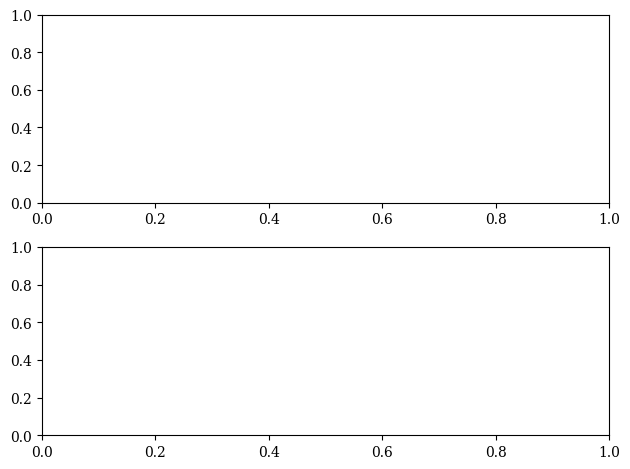

In [73]:
df1_left = flash_right_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('A2', 'a3')]
ax[1] = layout.axes[('A2', 'a4')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])




df1_left = sham_right_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]


a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True,)



fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3],spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)

ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)


yticklabels = [r'-$\pi$', r'-$\frac{\pi}{2}$', r'$0$', r'$\frac{\pi}{2}$', r'$\pi$']
ax[0].set_yticklabels(yticklabels)
ax[1].set_yticklabels(yticklabels)
ax[1].set_xticklabels(['-0.5','0','0.68','3'])
ax[1].set_xlabel('Time (s)')
ax[0].set_xticklabels(['', '', '', ''])


ax[0].set_ylabel('Course direction', labelpad=1)
ax[1].set_ylabel('Course direction', labelpad=1)
ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

layout.append_figure_to_layer(layout.figures['A2'], 'A2', cleartarget=True)


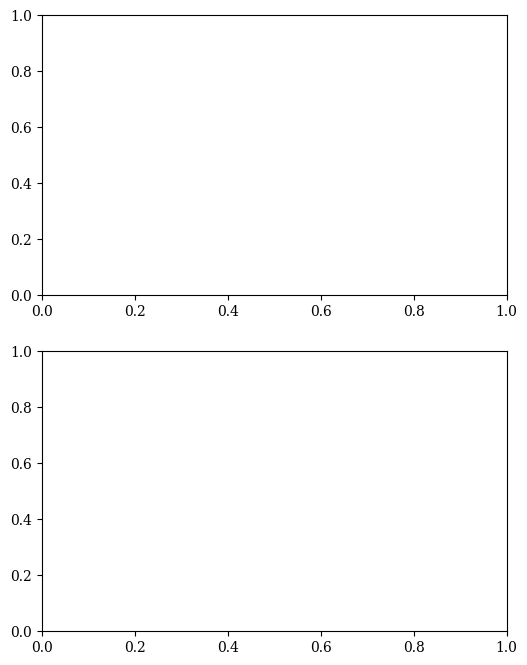

In [74]:
fig, ax = plt.subplots(figsize=(6,8), ncols=1,nrows=2)
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('B1', 'b1')]
ax[1] = layout.axes[('B1', 'b2')]

df1_left = flash_left_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
#df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['y'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])


df1_left = sham_left_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['y'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)


ax[0].set_yticklabels(['', '', ''])
ax[1].set_yticklabels(['', '', ''])
ax[1].set_xticklabels(['', '', '', ''])



ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

layout.append_figure_to_layer(layout.figures['B1'], 'B1', cleartarget=True)



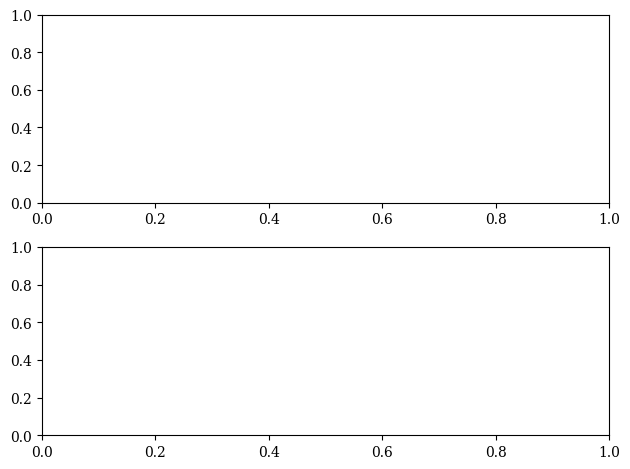

In [75]:
df1_left = flash_left_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('B2', 'b3')]
ax[1] = layout.axes[('B2', 'b4')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])




df1_left = sham_left_right_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]


a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True,)



fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3],spine_locations={'left':5, 'bottom':5},   tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[0], ['left'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi],spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)


ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)



ax[0].set_yticklabels([])
ax[1].set_yticklabels([])
ax[1].set_xticklabels([])
ax[0].set_xticklabels([])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
layout.append_figure_to_layer(layout.figures['B2'], 'B2', cleartarget=True)


# Left Fans On (y>0)

In [13]:
left1 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_leftlaminar/20240510_165159_full_trim_protocol.csv')
left2 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_leftlaminar/20240511_155654_full_trim_protocol.csv')
left3 = pd.read_csv('../../../Data/Experimental_Fly_Data/PreprocessedData/preprocessed_hdfs/VerticalSplit_leftlaminar/20240512_163544_full_trim_protocol.csv')


In [14]:
df_left_on = pd.concat([left1,left2,left3])

In [15]:
df_left_on['ground speed'] = np.sqrt(df_left_on.xvel**2 + df_left_on.yvel**2)

In [16]:
df_flash_left_on = df_left_on[df_left_on.duration>0]
df_sham_left_on =df_left_on[df_left_on.duration==0]


In [17]:
flash_left_left_on = df_flash_left_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()>0)
flash_right_left_on  = df_flash_left_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()<0)

sham_left_left_on =df_sham_left_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()>0)
sham_right_left_on =df_sham_left_on.groupby("obj_id_unique").filter(lambda d: d[d['time stamp'].between(0,675)].y.mean()<0)


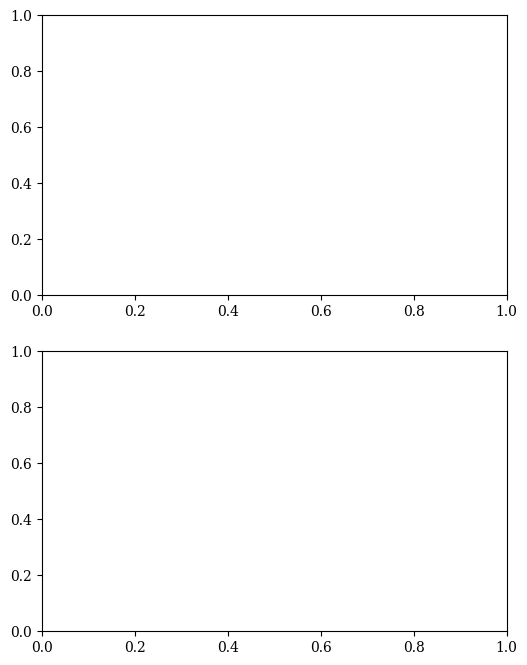

In [76]:
fig, ax = plt.subplots(figsize=(6,8), ncols=1,nrows=2)
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('C1', 'c1')]
ax[1] = layout.axes[('C1', 'c2')]

df1_left = flash_left_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
#df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['y'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])



df1_left = sham_left_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
#df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['y'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)


ax[0].set_yticklabels(['', '', ''])
ax[1].set_yticklabels(['', '', ''])
ax[1].set_xticklabels(['', '', '', ''])



ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
layout.append_figure_to_layer(layout.figures['C1'], 'C1', cleartarget=True)



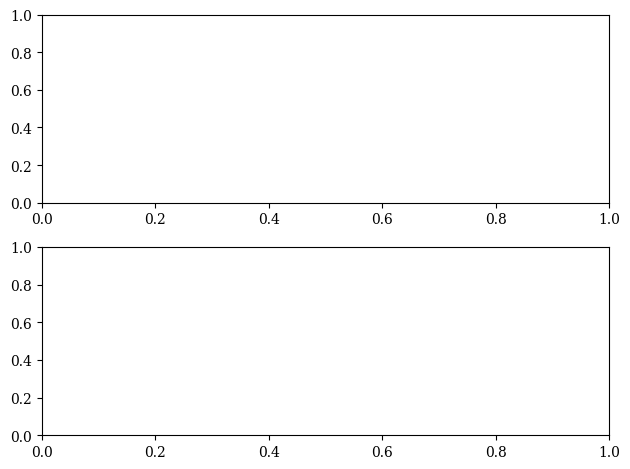

In [77]:
df1_left = flash_left_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('C2', 'c3')]
ax[1] = layout.axes[('C2', 'c4')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])




df1_left = sham_left_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]


a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True,)


fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[0], ['left'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)


ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)



ax[0].set_yticklabels([])
ax[1].set_yticklabels([])
ax[1].set_xticklabels([])
ax[0].set_xticklabels([])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)

layout.append_figure_to_layer(layout.figures['C2'], 'C2', cleartarget=True)


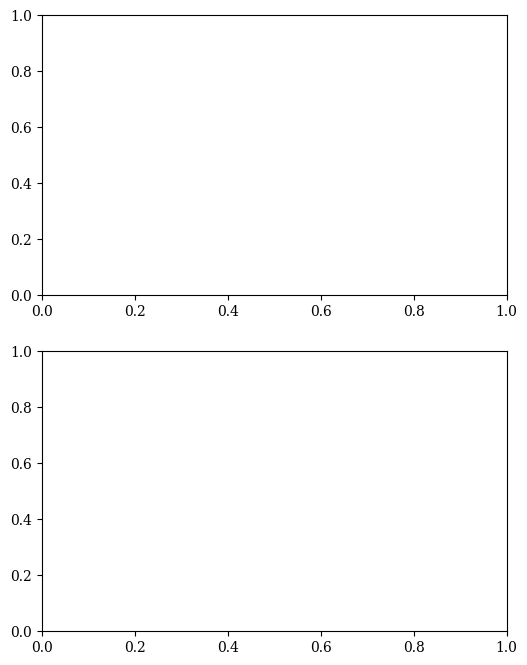

In [78]:
fig, ax = plt.subplots(figsize=(6,8), ncols=1,nrows=2)
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('D1', 'd1')]
ax[1] = layout.axes[('D1', 'd2')]

df1_left = flash_right_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
#df1_left = df1_left.groupby("obj_id_unique").filter(lambda d: np.any(d.duplicate_obj_id_bool)==False)
n_flash = len(df1_left.obj_id_unique.unique())
a = np.arange(-.500,3.000,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['y'], bins =(x,y), density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])



df1_left = sham_right_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.4))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]
a = np.arange(-.5,3,.010)
b =  np.linspace(-0.25, 0.25, 151)
y = np.linspace(-0.25, 0.25, 152)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['y'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=.05, cmap='bone_r', shading='flat', rasterized=True,)

fifi.mpl_functions.adjust_spines(ax[0], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3],spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
ax[0].set_xticklabels(['', '', '', ''])

fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-0.25,0,0.25,],  xticks=[-.5, 0, .68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)

    
ax[0].set_aspect(3.55) 
ax[1].set_aspect(3.55)


ax[0].set_yticklabels(['', '', ''])
ax[1].set_yticklabels(['', '', ''])
ax[1].set_xticklabels(['', '', '', ''])



ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=0.25, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
layout.append_figure_to_layer(layout.figures['D1'], 'D1', cleartarget=True)



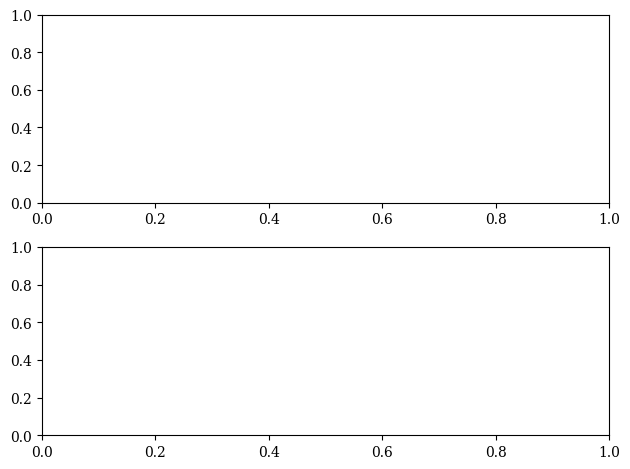

In [79]:
df1_left = flash_right_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
n_flash = len(df1_left.obj_id_unique.unique())
fig, ax = plt.subplots( ncols=1,nrows=2,layout='tight')
cmap_reversed = plt.colormaps.get_cmap('bone_r')
ax[0] = layout.axes[('D2', 'd3')]
ax[1] = layout.axes[('D2', 'd4')]


a = np.arange(-.500,3.000,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d( df1_left['time stamp']/1000,df1_left['heading'], bins =(x,y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[0].pcolormesh(X,Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True)
ax[0].set_xticklabels([])
ax[0].axvspan(0, .675, color = 'red', alpha = 0.1)



df1_left = sham_right_left_on.groupby(['obj_id']).filter(lambda d: d['ground speed'].mean()>=.15 )
sham_ids = df1_left[df1_left['time stamp']==0].groupby('obj_id_unique').filter(lambda d: (d['x'].between(-.35,0.35)) & (d['y'].between(-0.1,0.1)) & (d['z'].between(0.05,0.35))).obj_id_unique
df1_left = df1_left [df1_left.obj_id_unique.isin(list(sham_ids))]


a = np.arange(-.5,3,.010)
b = np.linspace(-np.pi, np.pi, 180)
y= np.linspace(-np.pi, np.pi, 181)
x = np.arange(-.500,3.010, .010)
X,Y = np.meshgrid(x,y)
bin_values,_,__ = np.histogram2d(df1_left['time stamp']/1000,df1_left['heading'],  bins =(x, y),density=True)
newdf_normed = pd.DataFrame((bin_values.T/np.sum(bin_values,axis=1)) ,columns=a, index=b)
ax[1].pcolormesh(X, Y, newdf_normed, vmin=0, vmax=0.05, cmap='bone_r', shading='flat', rasterized=True,)
ax[1].axvspan(0, .675, color = 'grey', alpha = 0.2)


fifi.mpl_functions.adjust_spines(ax[1], ['left','bottom'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi], xticks=[-0.5, 0, 0.68, 3], spine_locations={'left':5, 'bottom':5},  tick_length=3, linewidth=.5)
fifi.mpl_functions.adjust_spines(ax[0], ['left'], yticks =[-np.pi,-np.pi/2,0,np.pi/2, np.pi],spine_locations={'left':5, 'bottom':5}, tick_length=3, linewidth=.5)
ax[0].set_aspect(.3) 
ax[1].set_aspect(.3)


ax[0].set_yticklabels([])
ax[1].set_yticklabels([])
ax[1].set_xticklabels([])
ax[0].set_xticklabels([])


ax[0].axvspan(0, .675, color = 'red', edgecolor=None, alpha = 0.1)
ax[1].axvspan(0, .675, color = 'grey', edgecolor=None, alpha = 0.2) 

ax[0].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(n_flash), fontsize=5,fontstyle='italic',rotation=90, bbox=dict(facecolor='white', edgecolor='white', pad=0.05,alpha=0.7))
ax[1].text(x=3,y=np.pi, horizontalalignment='left', verticalalignment="top", s= 'n=' + str(len(df1_left.obj_id_unique.unique())), fontsize=5, rotation=90,fontstyle='italic', bbox=dict(facecolor='white', edgecolor='white',pad=0.05, alpha=0.7))


fifi.mpl_functions.set_fontsize(ax[0], 6)
fifi.mpl_functions.set_fontsize(ax[1], 6)
layout.append_figure_to_layer(layout.figures['D2'], 'D2', cleartarget=True)


# Sample Trajectories

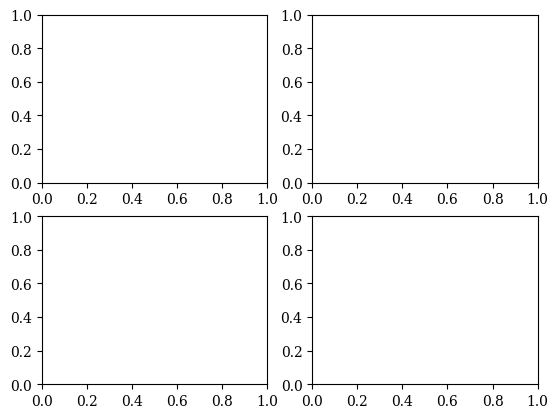

In [80]:

np.random.seed(3000)
trajs= np.random.choice(flash_right_right_on.groupby('obj_id_unique').filter(lambda d: (d['time stamp'].max()>=3000)).obj_id_unique.unique(),4,replace=False)
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('A_t', 't1_a')]
ax[0,1] = layout.axes[('A_t', 't2_a')]
ax[1,0] = layout.axes[('A_t', 't3_a')]
ax[1,1] = layout.axes[('A_t', 't4_a')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_right_right_on[flash_right_right_on['time stamp'].between(-200,3000)], trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['A_t'], 'A_t', cleartarget=True)


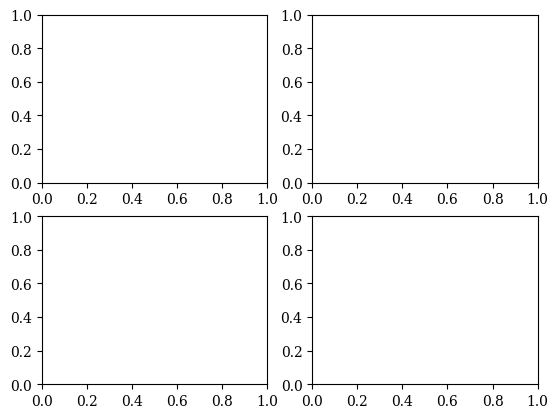

In [81]:
np.random.seed(300)
trajs= np.random.choice(flash_left_right_on.groupby('obj_id_unique').filter(lambda d: (d['time stamp'].max()>=3000)).obj_id_unique.unique(),4,replace=False)
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('B_t', 't1_b')]
ax[0,1] = layout.axes[('B_t', 't2_b')]
ax[1,0] = layout.axes[('B_t', 't3_b')]
ax[1,1] = layout.axes[('B_t', 't4_b')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_left_right_on[flash_left_right_on['time stamp'].between(-200,3000)], trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['B_t'], 'B_t', cleartarget=True)


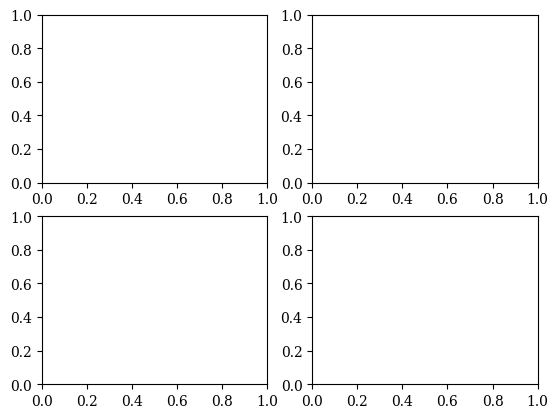

In [82]:
np.random.seed(20)
trajs= np.random.choice(flash_left_left_on.groupby('obj_id_unique').filter(lambda d: (d['time stamp'].max()>=3000)).obj_id_unique.unique(),4,replace=False)
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('C_t', 't1_c')]
ax[0,1] = layout.axes[('C_t', 't2_c')]
ax[1,0] = layout.axes[('C_t', 't3_c')]
ax[1,1] = layout.axes[('C_t', 't4_c')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_left_left_on[flash_left_left_on['time stamp'].between(-200,3000)], trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['C_t'], 'C_t', cleartarget=True)


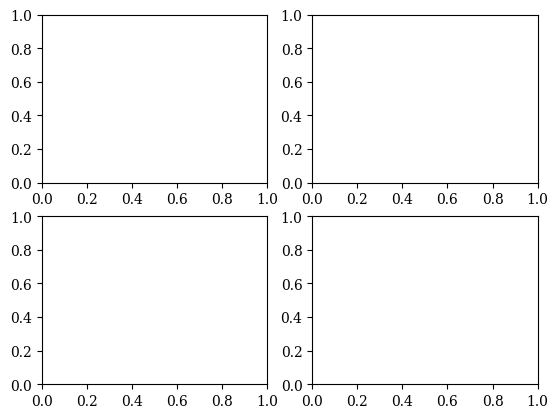

In [83]:
np.random.seed(500)
trajs= np.random.choice(flash_right_left_on.groupby('obj_id_unique').filter(lambda d: (d['time stamp'].max()>=3000)).obj_id_unique.unique(),4,replace=False)
fig, ax= plt.subplots(nrows=2,ncols=2)
ax[0,0] = layout.axes[('D_t', 't1_d')]
ax[0,1] = layout.axes[('D_t', 't2_d')]
ax[1,0] = layout.axes[('D_t', 't3_d')]
ax[1,1] = layout.axes[('D_t', 't4_d')]

for i, subplot in enumerate([ax[0,0], ax[0,1], ax[1,0], ax[1,1]]):
    get_subplot(flash_right_left_on[flash_right_left_on['time stamp'].between(-200,3000)], trajs[i], ax=subplot)


layout.append_figure_to_layer(layout.figures['D_t'], 'D_t', cleartarget=True)


In [84]:
layout.write_svg('S1_verticalsplit.svg')